# 1 — Exploratory analysis

What this notebook is for: deciding whether a battery on this site has anything worth optimizing, **before** any model is built.

Every figure answers a stated question. The plotting code lives in `bess_dispatch.visualization.eda` so it is testable and reusable; this notebook only narrates.

Data provenance, units, splits and the rescaling caveat are in `data/DATA_DICTIONARY.md`. The short version: real DE/LU wholesale prices, and national load and solar shapes rescaled to a hypothetical 1 MW / 0.8 MWp site.

In [1]:
%matplotlib inline

from bess_dispatch.data.loaders import (
    daily_price_spread,
    describe,
    load_site_frame,
    train_test_report,
)
from bess_dispatch.visualization import eda

frame = load_site_frame()
print(f'{len(frame):,} hourly rows, {frame.index[0]} to {frame.index[-1]}')

17,544 hourly rows, 2018-10-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00


## The splits

Chronological, never random — a random split over a time series leaks the future into the past.

The test window stops before March 2020 on purpose. European load and prices break structurally that month, and folding a once-in-a-decade shock into the headline would confound forecast quality with COVID. The `shift` split holds that period back to be looked at on its own.

In [2]:
train_test_report().round(2)

,start,end,rows,complete,imputed,whole_days,mean_price
split,,,,,,,
train,2018-10-01,2019-10-01,8760,8747,75,339,41.70
validation,2019-10-01,2020-01-01,2208,2208,3,91,36.59
test,2020-01-01,2020-03-01,1440,1440,0,60,28.66
shift,2020-03-01,2020-10-01,5136,5135,2,212,27.41


## Summary statistics

Note the price row: 484 negative hours, a minimum of −90 EUR/MWh and a maximum of 200. **No outliers are removed anywhere in this project.** Those extremes are real market events, and negative prices are precisely when a battery earns by charging — discarding them would delete the phenomenon under study.

In [3]:
describe(frame).round(2)

,n,mean,std,min,p05,median,p95,max,negative_hours
series,,,,,,,,,
load_mw,17536,0.72,0.13,0.42,0.52,0.71,0.93,1.00,NaN
pv_mw,17539,0.12,0.19,0.00,0.00,0.00,0.55,0.80,NaN
price_eur_mwh,17543,35.80,18.14,-90.01,4.99,36.15,63.90,200.04,484.0


## Q1 — Is demand in phase with expensive hours?

If load, price and PV all peaked together there would be little for a battery to do beyond self-consumption.

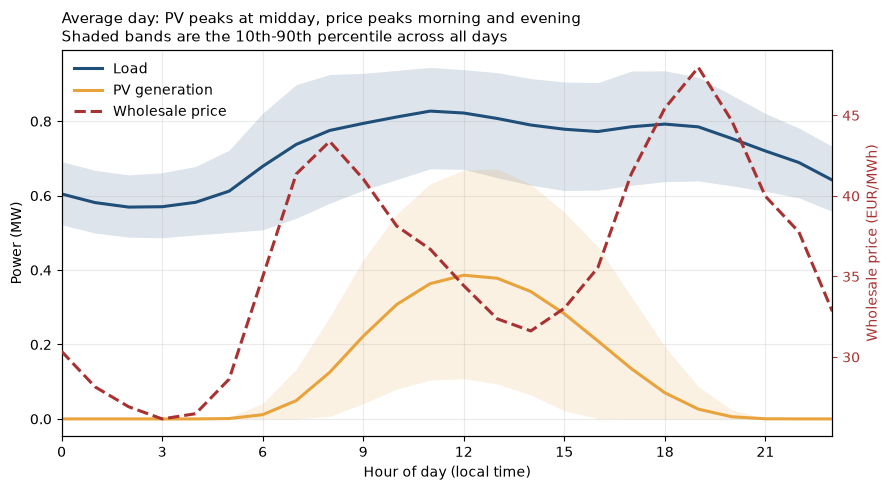

In [4]:
eda.plot_daily_profiles(frame);

They are not in phase, and that is the whole opportunity. Price is twin-peaked — morning and evening — with a **midday trough that PV helps dig**. Load is comparatively flat. So the battery has a standing invitation: charge into the cheap midday hours, discharge into the evening peak.

## Q2 — How much is one perfect cycle worth?

The within-day price spread is an upper bound on arbitrage revenue per MWh cycled, before round-trip losses. If the median day's spread were small relative to those losses, the battery would be better off idle.

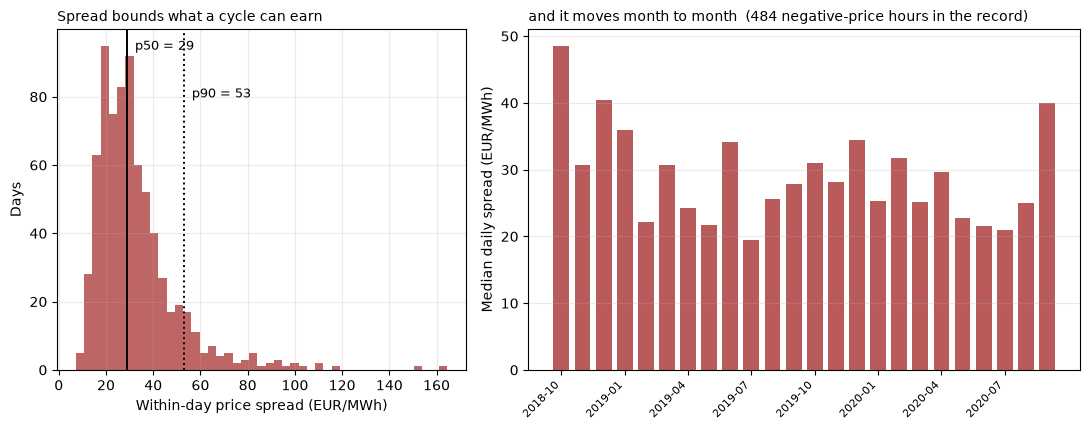

In [5]:
eda.plot_price_spread(frame);

In [6]:
spread = daily_price_spread(frame)
rte = 0.95 * 0.95
print(f'median daily spread   {spread.median():.1f} EUR/MWh')
print(f'90th percentile       {spread.quantile(0.9):.1f} EUR/MWh')
print(f'largest               {spread.max():.1f} EUR/MWh')
print()
print(f'round-trip efficiency {rte:.3f}: charging at price p and')
print('discharging at price q nets q*eta_d - p/eta_c per MWh stored,')
print('so the spread has to clear the loss before a cycle pays.')

median daily spread   28.7 EUR/MWh
90th percentile       52.8 EUR/MWh
largest               164.5 EUR/MWh

round-trip efficiency 0.902: charging at price p and
discharging at price q nets q*eta_d - p/eta_c per MWh stored,
so the spread has to clear the loss before a cycle pays.


The median day offers a spread around 29 EUR/MWh. That is comfortably above what round-trip losses cost at these price levels, so arbitrage is worth doing — but it is not enormous, and it sets expectations for how large the savings can be. The distribution has a long right tail: a handful of days offer more than 100 EUR/MWh, and those days will dominate the annual result.

## Q3 — Does PV push the site into export, and how peaky is import?

The duration curve answers both. Where it crosses zero is how many hours the site exports with no storage at all; its left-hand end is what a demand charge would be levied on.

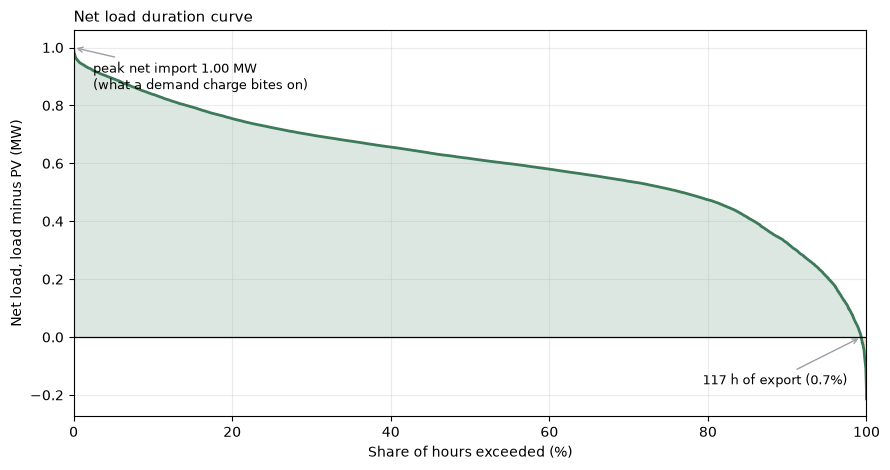

In [7]:
eda.plot_net_load_duration(frame);

The site exports in only 117 hours out of 17,531 — **0.7% of the time**. This matters for interpreting later results: export compensation is nearly irrelevant on this site, so the battery's value has to come from shifting *when* energy is imported, not from selling surplus. A sunnier site or a smaller load would tell a different story.

## Q4 — What intraday shape does the battery actually trade?

A raw hour-by-month heatmap of price would mislead here, and it is worth being explicit about why. The record runs 2018-10 to 2020-09, so months 10–12 come only from 2018 and 2019 while months 1–9 mix 2019 and 2020 — and 2019 averaged 37.7 EUR/MWh against 2020's 27.7. A raw heatmap shows that level shift between years and invites reading it as a seasonal effect.

Subtracting each day's own mean removes the level and leaves the within-day shape, which is also the only thing a daily-cycling battery can monetise.

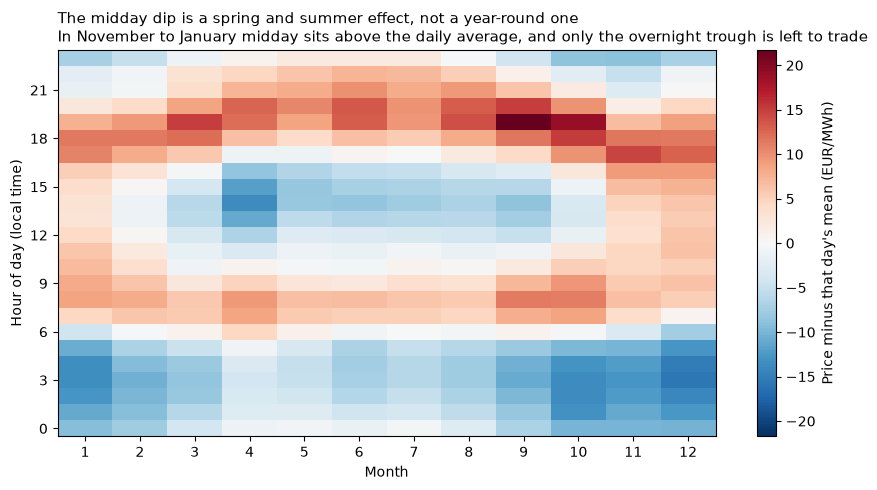

In [8]:
eda.plot_price_by_hour_and_month(frame);

The midday dip is **seasonal, not year-round**. From March to September midday sits well below the daily mean; from November to January it sits *above* it, and only the overnight trough is left to charge into. The evening peak around 18:00–20:00 is the one feature present all year.

This is why the feature set includes month-of-year: a forecaster without it cannot represent a signal that inverts between seasons.

## Q5 — Is price just a function of load and PV?

If it were, forecasting price would reduce to forecasting the other two, and it would not need its own model.

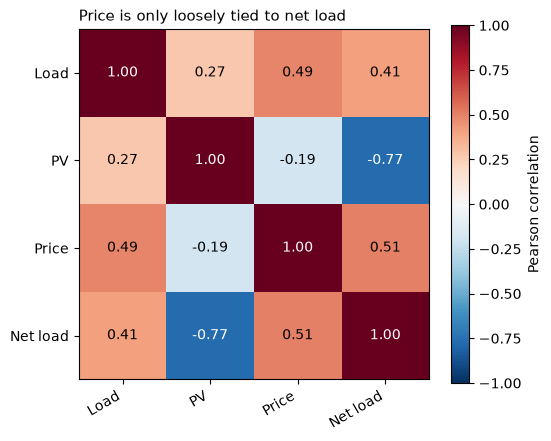

In [9]:
eda.plot_correlations(frame);

It is not. Price correlates with net load at only 0.51 — a real relationship, but far from determinative. Price carries information from fuel costs, cross-border flows, outages and wind that this site cannot see at all.

That has a direct consequence for the rest of the project: **price is the hardest of the three series to forecast, and it is also the one the dispatch decision is most sensitive to.** The ablation in the evaluation phase tests exactly that claim rather than assuming it.

## What this establishes

1. Price and load are out of phase, so there is arbitrage to capture beyond self-consumption.
2. The median day offers roughly 29 EUR/MWh of spread — worth capturing, but modest, so expect single-digit percentage savings from a modestly-sized battery.
3. The site almost never exports, so value must come from shifting import timing.
4. The tradeable intraday shape inverts between summer and winter.
5. Price is only loosely tied to load and PV, so it needs its own model and will likely be the binding constraint on performance.

Next: `bess_dispatch.forecasting` builds models for all three series, with a leakage test that is the single most important test in the repository.